# 🐑 Sheep Activity Classifier v3

### Cambios respecto a v2 (por qué val F1=1.0 pero test F1=0.55)

**Problema raíz:** ViT-Base tiene 86M parámetros para solo 100 videos → memoriza el conjunto de validación (que era de ~16 videos). El modelo no aprendía a generalizar.

**Soluciones aplicadas:**
1. **Backbone más pequeño**: `EfficientNet-B0` (5.3M params) en lugar de ViT-Base (86M). Mejor ratio parámetros/datos para datasets pequeños.
2. **Pseudo-labeling**: entrenar con train → predecir test con alta confianza → re-entrenar con train + pseudo-labels del test. Esto aprovecha los 169 videos de test sin etiquetas.
3. **Freeze total del backbone en ronda 1**, solo entrena el clasificador. En ronda 2 se descongela parcialmente (fine-tuning progresivo).
4. **Stochastic Depth** (drop path) como regularización adicional.
5. `n_frames` reducido a **8** (suficiente para capturar la actividad, reduce overfitting por frame).
6. K-Fold mantenido pero con **early stopping más agresivo** (patience=7).

### Por qué NO fusionar train+test para K-Fold
No tenemos etiquetas del test, así que no podemos usarlo directamente en K-Fold supervisado. El **pseudo-labeling** es la alternativa correcta.


In [32]:
ls checkpoints

final_phase1.pt  fold1.pt  fold3.pt  fold5.pt
final_phase2.pt  fold2.pt  fold4.pt  r1_test_predictions.csv


In [26]:
rm checkpoints/kfold_curves.png

## 0 · Instalación

In [1]:
!pip install -q timm>=0.9.0 ultralytics>=8.0.0 einops

## 1 · GPU, imports y config

In [2]:
import os, sys, math, random
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
from torch.amp import GradScaler, autocast
from torch.utils.data import DataLoader, WeightedRandomSampler, Dataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import timm
from PIL import Image
import torchvision.transforms.functional as TF
import torchvision.transforms as T

assert torch.cuda.is_available(), "⚠️ Activa la GPU en Settings → Accelerator."
DEVICE = torch.device("cuda")
print(f"✅ GPU : {torch.cuda.get_device_name(0)}")
print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"   PyTorch {torch.__version__} · CUDA {torch.version.cuda}")

✅ GPU : Tesla T4
   VRAM: 15.6 GB
   PyTorch 2.10.0+cu128 · CUDA 12.8


In [3]:
# ── Rutas ─────────────────────────────────────────────────────────────
WORKING_DIR = Path("/kaggle/working")
INPUT_DIR = Path("/kaggle/input")

# Data
TRAIN_VIDEO_DIR = WORKING_DIR / "train"
TEST_VIDEO_DIR = WORKING_DIR / "test"
LABEL_CSV = INPUT_DIR / "datasets/jeffreyamc/sheep-labels/train.csv"

print(f"TRAIN_DIR: {TRAIN_VIDEO_DIR}")
print(f"TEST_DIR: {TEST_VIDEO_DIR}")
print(f"LABEL_CSV: {LABEL_CSV}")

# Scripts
MODULES_DIR = INPUT_DIR / "datasets/jeffreyamc/modules/"

print(f"MODULES_DIR {MODULES_DIR}")

PROCESSED_DIR = WORKING_DIR / "processed"
CHECKPOINT_DIR = WORKING_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(exist_ok=True)

# Agregar scripts al path
sys.path.insert(0, str(MODULES_DIR))

# ── Config ─────────────────────────────────────────────────────────────
CFG = {
    # Preprocesamiento
    "n_frames"         : 8,           # ↓ de 16 → menos overfitting por frame
    "video_ext"        : ".mov",
    # Modelo
    "backbone"         : "efficientnet_b0",  # 5.3M params vs 86M del ViT-B
    "num_classes"      : 5,
    "dropout"          : 0.5,
    "unfreeze_blocks"  : 0,           # Fase 1: backbone 100% congelado
    # K-Fold
    "n_folds"          : 5,
    # Entrenamiento fase 1 (solo clasificador)
    "epochs_phase1"    : 30,
    "lr_phase1"        : 3e-4,
    # Entrenamiento fase 2 (fine-tuning parcial)
    "epochs_phase2"    : 20,
    "lr_phase2"        : 5e-5,
    "unfreeze_phase2"  : 3,           # Descongelar últimos 3 bloques en fase 2
    # Pseudo-labeling
    "pseudo_confidence": 0.85,        # Solo usar predicciones con prob >= 0.85
    "pseudo_epochs"    : 20,
    "pseudo_lr"        : 3e-5,
    # Común
    "batch_size"       : 16,
    "weight_decay"     : 0.01,
    "warmup_epochs"    : 3,
    "patience"         : 7,           # más agresivo que v2
    "mixup_prob"       : 0.4,
    "mixup_alpha"      : 0.3,
    "max_grad_norm"    : 1.0,
    "label_smoothing"  : 0.1,
    "num_workers"      : 2,
    "seed"             : 42,
    "use_tta"          : True,
    "tta_augments"     : 6,
}

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CFG["seed"])
print("Config cargada ✅")

TRAIN_DIR: /kaggle/working/train
TEST_DIR: /kaggle/working/test
LABEL_CSV: /kaggle/input/datasets/jeffreyamc/sheep-labels/train.csv
MODULES_DIR /kaggle/input/datasets/jeffreyamc/modules
Config cargada ✅


## 2 · Modelo EfficientNet

In [4]:
# ── Temporal Attention Pool ────────────────────────────────────────────
class TemporalAttentionPool(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 4), nn.Tanh(),
            nn.Linear(embed_dim // 4, 1),
        )
    def forward(self, x):  # x: (B, N, D)
        w = F.softmax(self.attention(x), dim=1)  # (B, N, 1)
        return (w * x).sum(dim=1)                # (B, D)


# ── Clasificador principal ─────────────────────────────────────────────
class SheepClassifier(nn.Module):
    """
    EfficientNet-B0 como backbone (5.3M params, mucho más adecuado para 100 videos)
    + Temporal Attention Pool sobre los N frames
    + MLP clasificador con Dropout fuerte
    """
    def __init__(self, num_classes=5, n_frames=8, backbone_name="efficientnet_b0",
                 dropout=0.5, unfreeze_last_n=0):
        super().__init__()
        self.n_frames = n_frames

        self.backbone = timm.create_model(
            backbone_name, pretrained=True, num_classes=0, global_pool="avg"
        )
        embed_dim = self.backbone.num_features  # 1280 para B0

        self._set_frozen(unfreeze_last_n)
        self.temporal_pool = TemporalAttentionPool(embed_dim)
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout * 0.6),
            nn.Linear(256, num_classes),
        )
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def _set_frozen(self, unfreeze_last_n: int):
        """Congela todo el backbone excepto los últimos N bloques."""
        for p in self.backbone.parameters():
            p.requires_grad = False

        if unfreeze_last_n > 0:
            # EfficientNet tiene bloques en backbone.blocks
            blocks = list(self.backbone.blocks)
            for block in blocks[-unfreeze_last_n:]:
                for p in block.parameters():
                    p.requires_grad = True
            # Descongelar también conv_head y bn2
            for name in ["conv_head", "bn2"]:
                layer = getattr(self.backbone, name, None)
                if layer:
                    for p in layer.parameters():
                        p.requires_grad = True

        total     = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"  Params totales: {total/1e6:.2f}M | Entrenables: {trainable/1e6:.2f}M ({100*trainable/total:.1f}%)")

    def forward(self, clip):  # clip: (B, N, C, H, W)
        B, N, C, H, W = clip.shape
        frames = clip.view(B * N, C, H, W)
        emb    = self.backbone(frames).view(B, N, -1)  # (B, N, D)
        pooled = self.temporal_pool(emb)               # (B, D)
        return self.classifier(pooled)                 # (B, num_classes)


# ── Label Smoothing con soporte para targets suaves (Mixup) ───────────
class SmoothedCE(nn.Module):
    def __init__(self, smoothing=0.1, num_classes=5):
        super().__init__()
        self.smoothing = smoothing
        self.num_classes = num_classes

    def forward(self, logits, targets):
        log_p = F.log_softmax(logits, dim=-1)
        if targets.dim() == 1:
            oh = torch.zeros_like(log_p).fill_(self.smoothing / (self.num_classes - 1))
            oh.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        else:
            oh = targets * (1 - self.smoothing) + self.smoothing / self.num_classes
        return -(oh * log_p).sum(dim=-1).mean()


def build_model(unfreeze=0):
    m = SheepClassifier(
        num_classes=CFG["num_classes"],
        n_frames=CFG["n_frames"],
        backbone_name=CFG["backbone"],
        dropout=CFG["dropout"],
        unfreeze_last_n=unfreeze,
    ).to(DEVICE)
    return m

print("Arquitectura definida ✅")
# Test rápido de shapes
_m = build_model(0)
_x = torch.randn(2, CFG["n_frames"], 3, 224, 224).to(DEVICE)
with torch.no_grad():
    _out = _m(_x)
print(f"  Output shape: {_out.shape}  (esperado: [2, 5])")
del _m, _x, _out
torch.cuda.empty_cache()

Arquitectura definida ✅


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

  Params totales: 4.01M | Entrenables: 0.00M (0.0%)
  Output shape: torch.Size([2, 5])  (esperado: [2, 5])


## 3 · Dataset con augmentation mejorada

In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_SIZE = 224


class TemporalConsistentTransform:
    """
    Misma transformación espacial para todos los frames del clip.
    Augmentation más fuerte que v2 para compensar dataset pequeño.
    """
    def __init__(self, is_train=True):
        self.is_train = is_train
        self.to_tensor = T.ToTensor()
        self.normalize = T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
        self.erase = T.RandomErasing(p=0.35, scale=(0.02, 0.2))

    def __call__(self, frames):
        if self.is_train:
            # Parámetros aleatorios compartidos
            i, j, h, w = T.RandomResizedCrop.get_params(
                frames[0], scale=(0.65, 1.0), ratio=(0.8, 1.2)
            )
            flip_h  = random.random() < 0.5
            flip_v  = random.random() < 0.15
            angle   = random.uniform(-25, 25)
            bright  = random.uniform(0.5, 1.5)
            contrast= random.uniform(0.5, 1.5)
            sat     = random.uniform(0.6, 1.4)
            hue     = random.uniform(-0.15, 0.15)
            do_gray = random.random() < 0.08
            blur_s  = random.uniform(0.1, 2.5) if random.random() < 0.4 else None

        out = []
        for f in frames:
            if self.is_train:
                f = TF.resized_crop(f, i, j, h, w, (IMG_SIZE, IMG_SIZE))
                if flip_h: f = TF.hflip(f)
                if flip_v: f = TF.vflip(f)
                f = TF.rotate(f, angle)
                f = TF.adjust_brightness(f, bright)
                f = TF.adjust_contrast(f, contrast)
                f = TF.adjust_saturation(f, sat)
                f = TF.adjust_hue(f, hue)
                if do_gray: f = TF.rgb_to_grayscale(f, num_output_channels=3)
                if blur_s:  f = TF.gaussian_blur(f, kernel_size=5, sigma=blur_s)
            else:
                f = f.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
            t = self.normalize(self.to_tensor(f))
            if self.is_train:
                t = self.erase(t)
            out.append(t)
        return torch.stack(out)  # (N, C, H, W)


class SheepDataset(Dataset):
    """
    processed_dir : carpeta con subcarpetas por video_id
    labels_df     : DataFrame con [Id, Target], o None para test
    pseudo_df     : DataFrame adicional con pseudo-labels [Id, Target]
    """
    def __init__(self, processed_dir, labels_df=None, pseudo_df=None,
                 n_frames=8, is_train=True):
        self.root     = Path(processed_dir)
        self.n_frames = n_frames
        self.transform = TemporalConsistentTransform(is_train)

        if labels_df is not None:
            df = labels_df.copy()
            if pseudo_df is not None:
                df = pd.concat([df, pseudo_df], ignore_index=True)
            self.samples = [
                (str(row["Id"]), int(row["Target"]))
                for _, row in df.iterrows()
                if (self.root / str(row["Id"])).exists()
            ]
        else:
            self.samples = [
                (d.name, -1)
                for d in sorted(self.root.iterdir()) if d.is_dir()
            ]
        print(f"  Dataset: {len(self.samples)} muestras ({'train' if is_train else 'val/test'})")

    def _load_frames(self, video_id):
        vid_dir = self.root / video_id
        files   = sorted(vid_dir.glob("frame_*.png"))
        frames  = [Image.open(f).convert("RGB") for f in files]
        while len(frames) < self.n_frames:
            frames.append(frames[-1] if frames else Image.new("RGB", (IMG_SIZE, IMG_SIZE)))
        if len(frames) > self.n_frames:
            idx    = np.linspace(0, len(frames)-1, self.n_frames, dtype=int)
            frames = [frames[i] for i in idx]
        return frames[:self.n_frames]

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        vid_id, label = self.samples[idx]
        clip = self.transform(self._load_frames(vid_id))
        return {"clip": clip, "label": torch.tensor(label, dtype=torch.long), "video_id": vid_id}


def mixup_batch(clips, labels, num_classes, alpha=0.3):
    lam   = np.random.beta(alpha, alpha)
    idx   = torch.randperm(clips.size(0), device=clips.device)
    mixed = lam * clips + (1 - lam) * clips[idx]
    oh    = torch.zeros(clips.size(0), num_classes, device=clips.device)
    oh.scatter_(1, labels.unsqueeze(1), 1)
    return mixed, lam * oh + (1 - lam) * oh[idx]


def make_sampler(labels):
    counts  = Counter(labels)
    weights = [1.0 / counts[l] for l in labels]
    return WeightedRandomSampler(weights, len(weights), replacement=True)


def compute_class_weights(labels, num_classes=5):
    counts  = Counter(labels)
    total   = len(labels)
    w = torch.tensor([total / (num_classes * counts.get(i, 1)) for i in range(num_classes)],
                     dtype=torch.float32)
    return (w / w.sum() * num_classes).to(DEVICE)


def oversample_df(df, strategy="median"):
    counts   = df["Target"].value_counts()
    target_n = int(counts.median()) if strategy == "median" else int(counts.max())
    parts = [df]
    for cls, cnt in counts.items():
        if cnt < target_n:
            extra = df[df["Target"] == cls].sample(n=target_n - cnt, replace=True, random_state=42)
            parts.append(extra)
    return pd.concat(parts, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print("Dataset y transforms definidos ✅")

Dataset y transforms definidos ✅


## 4 · Preprocesamiento de videos

In [6]:
from preprocess import load_yolo, process_video
yolo = load_yolo("yolov8m.pt")
print("✅ YOLO listo")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
[YOLO] Cargando modelo yolov8m.pt...
[INFO] ¡GPU detectada! Moviendo modelo a CUDA.
✅ YOLO listo


In [7]:
def preprocess_split(video_dir, split, yolo_model):
    out_root    = PROCESSED_DIR / split
    video_files = sorted(Path(video_dir).glob(f"*{CFG['video_ext']}"))
    if not video_files:
        video_files = sorted(Path(video_dir).glob("*.mp4"))
    print(f"[{split.upper()}] {len(video_files)} videos")
    for vf in tqdm(video_files, desc=split):
        out = out_root / vf.stem
        if out.exists() and len(list(out.glob("*.png"))) == CFG["n_frames"]:
            continue
        process_video(str(vf), yolo_model, str(out), vf.stem, CFG["n_frames"])
    print("  ✅ Listo")

preprocess_split(TRAIN_VIDEO_DIR, "train", yolo)
preprocess_split(TEST_VIDEO_DIR,  "test",  yolo)

del yolo; torch.cuda.empty_cache()
print("🧹 YOLO liberado")

[TRAIN] 100 videos


train:   0%|          | 0/100 [00:00<?, ?it/s]

  ✅ Listo
[TEST] 169 videos


test:   0%|          | 0/169 [00:00<?, ?it/s]

  ✅ Listo
🧹 YOLO liberado


## 5 · Utilidades de entrenamiento

In [8]:
def cosine_warmup(optimizer, warmup, total):
    def f(ep):
        if ep < warmup: return (ep + 1) / warmup
        p = (ep - warmup) / max(1, total - warmup)
        return 0.5 * (1 + math.cos(math.pi * p))
    return LambdaLR(optimizer, f)

class EarlyStopping:
    def __init__(self, patience=7, delta=1e-4):
        self.p = patience; self.d = delta
        self.c = 0; self.best = None
    def step(self, s):
        if self.best is None or s > self.best + self.d:
            self.best = s; self.c = 0; return False
        self.c += 1; return self.c >= self.p

def make_optimizer(model, lr):
    decay, nodecay = [], []
    for n, p in model.named_parameters():
        if not p.requires_grad: continue
        (nodecay if ("bias" in n or "norm" in n or "bn" in n) else decay).append(p)
    return AdamW([{"params": decay, "weight_decay": CFG["weight_decay"]},
                  {"params": nodecay, "weight_decay": 0.0}], lr=lr)


def run_epoch(model, loader, optimizer, criterion, scaler, is_train):
    model.train() if is_train else model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    ctx = torch.enable_grad() if is_train else torch.no_grad()

    with ctx:
        for batch in tqdm(loader, desc=" Train" if is_train else "  Val ", leave=False):
            clips  = batch["clip"].to(DEVICE, non_blocking=True)
            labels = batch["label"].to(DEVICE, non_blocking=True)

            use_mix = is_train and (np.random.random() < CFG["mixup_prob"])
            if use_mix:
                clips, labels_s = mixup_batch(clips, labels, CFG["num_classes"], CFG["mixup_alpha"])

            if is_train: optimizer.zero_grad(set_to_none=True)

            with autocast("cuda"):
                logits = model(clips)
                loss   = criterion(logits, labels_s if use_mix else labels)

            if is_train:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), CFG["max_grad_norm"])
                scaler.step(optimizer); scaler.update()

            total_loss += loss.item()
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(batch["label"].numpy())

    f1_pc = f1_score(all_labels, all_preds, average=None, zero_division=0)
    return {"loss": total_loss / len(loader), "macro_f1": float(f1_pc.mean()), "f1_pc": f1_pc.tolist()}


def train_fold(train_df, val_df, fold_n, pseudo_df=None):
    """
    Entrena un fold en 2 fases:
    Fase 1: backbone congelado, solo clasificador
    Fase 2: fine-tuning de los últimos N bloques
    Retorna el mejor F1 de validación y el path del checkpoint.
    """
    print(f"\n{'─'*60}")
    print(f"  FOLD {fold_n}  |  Train: {len(train_df)}  |  Val: {len(val_df)}")
    if pseudo_df is not None:
        print(f"  + {len(pseudo_df)} pseudo-labels")
    print(f"{'─'*60}")

    train_os = oversample_df(train_df)
    if pseudo_df is not None:
        # Los pseudo-labels se añaden sin oversample extra
        train_ds = SheepDataset(str(PROCESSED_DIR / "train"), train_os,
                                pseudo_df=pseudo_df, n_frames=CFG["n_frames"], is_train=True)
    else:
        train_ds = SheepDataset(str(PROCESSED_DIR / "train"), train_os,
                                n_frames=CFG["n_frames"], is_train=True)
    val_ds   = SheepDataset(str(PROCESSED_DIR / "train"), val_df,
                            n_frames=CFG["n_frames"], is_train=False)

    sampler      = make_sampler(train_os["Target"].tolist())
    train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], sampler=sampler,
                              num_workers=CFG["num_workers"], pin_memory=True, drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=CFG["batch_size"], shuffle=False,
                              num_workers=CFG["num_workers"], pin_memory=True)

    best_f1   = 0.0
    ckpt_path = CHECKPOINT_DIR / f"fold{fold_n}.pt"
    history   = []

    for phase, (n_ep, lr, unfreeze) in enumerate([
        (CFG["epochs_phase1"], CFG["lr_phase1"], 0),
        (CFG["epochs_phase2"], CFG["lr_phase2"], CFG["unfreeze_phase2"]),
    ], 1):
        print(f"\n  ── Fase {phase}: lr={lr}, unfreeze={unfreeze} bloques, {n_ep} épocas ──")
        model = build_model(unfreeze).to(DEVICE)

        # En fase 2, cargar pesos de fase 1
        if phase == 2 and ckpt_path.exists():
            state = torch.load(ckpt_path, map_location=DEVICE)["model_state"]
            state = {k.replace("_orig_mod.", ""): v for k, v in state.items()}
            model.load_state_dict(state, strict=False)
            print("  Pesos de fase 1 cargados")

        if torch.__version__ >= "2.0.0":
            try: model = torch.compile(model, mode="reduce-overhead")
            except: pass

        cw        = compute_class_weights(train_os["Target"].tolist())
        criterion = SmoothedCE(CFG["label_smoothing"], CFG["num_classes"])
        optimizer = make_optimizer(model, lr)
        scheduler = cosine_warmup(optimizer, CFG["warmup_epochs"], n_ep)
        scaler    = GradScaler("cuda")
        es        = EarlyStopping(CFG["patience"])

        for ep in range(1, n_ep + 1):
            lr_now = optimizer.param_groups[0]["lr"]
            tr = run_epoch(model, train_loader, optimizer, criterion, scaler, True)
            va = run_epoch(model, val_loader,   optimizer, criterion, scaler, False)
            scheduler.step()

            history.append({"fold": fold_n, "phase": phase, "epoch": ep,
                            "train_f1": tr["macro_f1"], "val_f1": va["macro_f1"],
                            "train_loss": tr["loss"],   "val_loss": va["loss"]})

            tag = " ✓ BEST" if va["macro_f1"] > best_f1 else ""
            print(f"  Ph{phase} Ep{ep:3d} | lr={lr_now:.1e} | "
                  f"Tr L={tr['loss']:.3f} F1={tr['macro_f1']:.3f} | "
                  f"Va L={va['loss']:.3f} F1={va['macro_f1']:.3f}{tag}")
            print(f"    F1/clase: {[f'{v:.2f}' for v in va['f1_pc']]}")

            if va["macro_f1"] > best_f1:
                best_f1 = va["macro_f1"]
                torch.save({"model_state": model.state_dict(),
                            "val_f1": best_f1, "cfg": CFG}, ckpt_path)
            if es.step(va["macro_f1"]):
                print(f"  ⏹ Early stop (fase {phase}, época {ep})")
                break

        del model; torch.cuda.empty_cache()

    return best_f1, str(ckpt_path), history

print("Utilidades definidas ✅")

Utilidades definidas ✅


## 6 · K-Fold — Ronda 1 (solo con train.csv)

In [10]:
m = build_model(unfreeze=0)
trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f"Parámetros entrenables: {trainable:,}")
for name, p in m.named_parameters():
    if p.requires_grad:
        print(f"  ✓ {name}")

  Params totales: 4.01M | Entrenables: 0.00M (0.0%)
Parámetros entrenables: 742,022
  ✓ temporal_pool.attention.0.weight
  ✓ temporal_pool.attention.0.bias
  ✓ temporal_pool.attention.2.weight
  ✓ temporal_pool.attention.2.bias
  ✓ classifier.0.weight
  ✓ classifier.0.bias
  ✓ classifier.2.weight
  ✓ classifier.2.bias
  ✓ classifier.5.weight
  ✓ classifier.5.bias


In [29]:
m = build_model(unfreeze=0)
print("Parámetros entrenables:")
for name, p in m.named_parameters():
    if p.requires_grad:
        print(f"  ✓ {name} — {p.numel():,}")

  Params totales: 4.01M | Entrenables: 0.00M (0.0%)
Parámetros entrenables:
  ✓ temporal_pool.attention.0.weight — 409,600
  ✓ temporal_pool.attention.0.bias — 320
  ✓ temporal_pool.attention.2.weight — 320
  ✓ temporal_pool.attention.2.bias — 1
  ✓ classifier.0.weight — 1,280
  ✓ classifier.0.bias — 1,280
  ✓ classifier.2.weight — 327,680
  ✓ classifier.2.bias — 256
  ✓ classifier.5.weight — 1,280
  ✓ classifier.5.bias — 5


In [11]:
df = pd.read_csv(LABEL_CSV)
df.columns = ["Id", "Target"]
print(f"Train: {len(df)} videos")
print(df["Target"].value_counts().sort_index())

skf = StratifiedKFold(n_splits=CFG["n_folds"], shuffle=True, random_state=CFG["seed"])

fold_results   = []
fold_ckpts     = []
all_history    = []

print(f"\n{'='*60}")
print(f"  RONDA 1: K-Fold con datos de train únicamente")
print(f"{'='*60}")

for fold, (tr_idx, va_idx) in enumerate(skf.split(df["Id"], df["Target"])):
    set_seed(CFG["seed"] + fold)
    tr_df = df.iloc[tr_idx].reset_index(drop=True)
    va_df = df.iloc[va_idx].reset_index(drop=True)
    best_f1, ckpt, history = train_fold(tr_df, va_df, fold + 1)
    fold_results.append(best_f1)
    fold_ckpts.append(ckpt)
    all_history.extend(history)
    print(f"  ✅ Fold {fold+1} → Best Val F1 = {best_f1:.4f}")

print(f"\n{'='*60}")
print(f"  K-Fold Ronda 1 completo")
for i, f1 in enumerate(fold_results): print(f"  Fold {i+1}: {f1:.4f}")
print(f"  Media: {np.mean(fold_results):.4f} ± {np.std(fold_results):.4f}")
print(f"{'='*60}")

Train: 100 videos
Target
0    22
1    13
2    28
3    29
4     8
Name: count, dtype: int64

  RONDA 1: K-Fold con datos de train únicamente

────────────────────────────────────────────────────────────
  FOLD 1  |  Train: 80  |  Val: 20
────────────────────────────────────────────────────────────
  Dataset: 97 muestras (train)
  Dataset: 20 muestras (val/test)

  ── Fase 1: lr=0.0003, unfreeze=0 bloques, 30 épocas ──
  Params totales: 4.01M | Entrenables: 0.00M (0.0%)


 Train:   0%|          | 0/6 [00:00<?, ?it/s]

  Val :   0%|          | 0/2 [00:00<?, ?it/s]

  Ph1 Ep  1 | lr=1.0e-04 | Tr L=2.702 F1=0.222 | Va L=1.845 F1=0.101 ✓ BEST
    F1/clase: ['0.36', '0.00', '0.14', '0.00', '0.00']


 Train:   0%|          | 0/6 [00:00<?, ?it/s]

...

  Val :   0%|          | 0/2 [00:00<?, ?it/s]

  Ph2 Ep  7 | lr=4.6e-05 | Tr L=1.305 F1=0.677 | Va L=0.757 F1=0.815
    F1/clase: ['0.80', '1.00', '0.73', '0.75', '0.80']


 Train:   0%|          | 0/6 [00:00<?, ?it/s]

  Val :   0%|          | 0/2 [00:00<?, ?it/s]

  Ph2 Ep  8 | lr=4.3e-05 | Tr L=1.310 F1=0.665 | Va L=0.744 F1=0.815
    F1/clase: ['0.80', '1.00', '0.73', '0.75', '0.80']
  ⏹ Early stop (fase 2, época 8)
  ✅ Fold 5 → Best Val F1 = 0.8155

  K-Fold Ronda 1 completo
  Fold 1: 0.7166
  Fold 2: 0.8598
  Fold 3: 0.8500
  Fold 4: 0.8598
  Fold 5: 0.8155
  Media: 0.8203 ± 0.0544


## 7 · Pseudo-labeling del test
Usamos el ensemble de los 5 folds para predecir el test y nos quedamos solo con las predicciones de alta confianza (prob >= 0.85). Esas se usan como etiquetas adicionales en la Ronda 2.

In [28]:
def load_model_for_inference(ckpt_path):
    ckpt  = torch.load(ckpt_path, map_location=DEVICE)
    cfg_  = ckpt.get("cfg", CFG)
    m = SheepClassifier(
        num_classes=cfg_["num_classes"], n_frames=cfg_["n_frames"],
        backbone_name=cfg_["backbone"],  dropout=0.0, unfreeze_last_n=0,
    ).to(DEVICE)
    state = {k.replace("_orig_mod.", ""): v for k, v in ckpt["model_state"].items()}
    m.load_state_dict(state, strict=False)
    m.eval()
    return m


@torch.no_grad()
def ensemble_predict_proba(models, frames_pil, n_tta=4):
    """Ensemble + TTA → array de probabilidades (num_classes,)"""
    all_p = []
    tf_v  = TemporalConsistentTransform(is_train=False)
    tf_a  = TemporalConsistentTransform(is_train=True)
    for m in models:
        clip = tf_v(frames_pil).unsqueeze(0).to(DEVICE)
        with autocast("cuda"): all_p.append(F.softmax(m(clip), dim=-1).cpu().numpy())
        for _ in range(n_tta - 1):
            clip = tf_a(frames_pil).unsqueeze(0).to(DEVICE)
            with autocast("cuda"): all_p.append(F.softmax(m(clip), dim=-1).cpu().numpy())
    return np.mean(all_p, axis=0)[0]  # (num_classes,)


# Cargar modelos de ronda 1
torch.backends.cudnn.benchmark = True
r1_models = [load_model_for_inference(p) for p in fold_ckpts]
print(f"\n{len(r1_models)} modelos de Ronda 1 cargados")

# Predecir test
test_ds = SheepDataset(str(PROCESSED_DIR / "test"), n_frames=CFG["n_frames"], is_train=False)
print(f"Videos de test: {len(test_ds)}")

pseudo_records = []
all_test_probs = []

for idx in tqdm(range(len(test_ds)), desc="Pseudo-labeling"):
    vid_id = test_ds.samples[idx][0]
    frames = test_ds._load_frames(vid_id)
    probs  = ensemble_predict_proba(r1_models, frames, n_tta=4)
    conf   = float(probs.max())
    pred   = int(probs.argmax())
    all_test_probs.append({"Id": vid_id, "Predicted": pred, "Confidence": conf})
    if conf >= CFG["pseudo_confidence"]:
        pseudo_records.append({"Id": vid_id, "Target": pred})

pseudo_df  = pd.DataFrame(pseudo_records)
all_preds_df = pd.DataFrame(all_test_probs)

print(f"\n✅ Pseudo-labels generados")
print(f"  Videos de test      : {len(all_test_probs)}")
print(f"  Con confianza ≥ {CFG['pseudo_confidence']}: {len(pseudo_df)} ({100*len(pseudo_df)/len(all_test_probs):.0f}%)")
print(f"  Distribución pseudo-labels:")
if len(pseudo_df) > 0:
    print(pseudo_df["Target"].value_counts().sort_index())

# Guardar para análisis
all_preds_df.to_csv(CHECKPOINT_DIR / "r1_test_predictions.csv", index=False)

# Liberar modelos de r1
del r1_models; torch.cuda.empty_cache()

  Params totales: 4.01M | Entrenables: 0.00M (0.0%)
  Params totales: 4.01M | Entrenables: 0.00M (0.0%)
  Params totales: 4.01M | Entrenables: 0.00M (0.0%)
  Params totales: 4.01M | Entrenables: 0.00M (0.0%)
  Params totales: 4.01M | Entrenables: 0.00M (0.0%)

5 modelos de Ronda 1 cargados
  Dataset: 169 muestras (val/test)
Videos de test: 169


Pseudo-labeling:   0%|          | 0/169 [00:00<?, ?it/s]


✅ Pseudo-labels generados
  Videos de test      : 169
  Con confianza ≥ 0.85: 0 (0%)
  Distribución pseudo-labels:


Pseudo-labels con conf ≥ 0.60: 32
Target
0     9
1     6
2     3
3    13
4     1
Name: count, dtype: int64


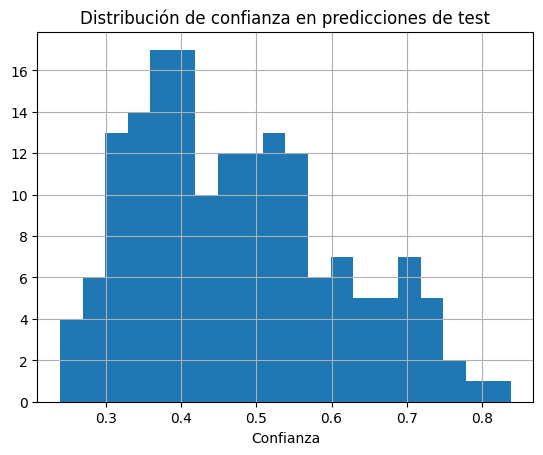

Confianza media: 0.475
Confianza máxima: 0.838


In [30]:
# Regenerar pseudo-labels con umbral más bajo
pseudo_records = []
for _, row in all_preds_df.iterrows():
    if row["Confidence"] >= 0.60:
        pseudo_records.append({"Id": row["Id"], "Target": row["Predicted"]})

pseudo_df = pd.DataFrame(pseudo_records)
print(f"Pseudo-labels con conf ≥ 0.60: {len(pseudo_df)}")
print(pseudo_df["Target"].value_counts().sort_index())

# Ver distribución de confianzas para entender el modelo
import matplotlib.pyplot as plt
all_preds_df["Confidence"].hist(bins=20)
plt.xlabel("Confianza"); plt.title("Distribución de confianza en predicciones de test")
plt.show()
print(f"Confianza media: {all_preds_df['Confidence'].mean():.3f}")
print(f"Confianza máxima: {all_preds_df['Confidence'].max():.3f}")

## 8 · K-Fold — Ronda 2 (train + pseudo-labels)

In [ ]:
# Si no hay suficientes pseudo-labels, ajustar confianza automáticamente
if len(pseudo_df) < 20:
    lower_conf = CFG["pseudo_confidence"] - 0.1
    print(f"⚠️  Pocos pseudo-labels. Bajando confianza a {lower_conf}")
    pseudo_df = pd.DataFrame([
        {"Id": r["Id"], "Target": r["Predicted"]}
        for _, r in all_preds_df.iterrows() if r["Confidence"] >= lower_conf
    ])
    print(f"  Pseudo-labels con conf ≥ {lower_conf}: {len(pseudo_df)}")

print(f"\n{'='*60}")
print(f"  RONDA 2: K-Fold con train + {len(pseudo_df)} pseudo-labels")
print(f"{'='*60}")

# Los pseudo-labels usan la carpeta de test procesado
# Necesitamos un dataset combinado
# Truco: creamos un symlink o apuntamos al directorio correcto en SheepDataset
# La solución más limpia: usar processed_dir="train" para labels reales
# y processed_dir="test" para pseudo → manejar en el dataset

# Adaptamos pseudo_df para indicar que sus frames están en /test
# Añadimos un prefijo especial que SheepDataset resolverá
pseudo_df_r2 = pseudo_df.copy()
# Creamos symlinks de test → train para que el dataset los encuentre
import shutil
pseudo_count = 0
for _, row in pseudo_df_r2.iterrows():
    src = PROCESSED_DIR / "test"  / str(row["Id"])
    dst = PROCESSED_DIR / "train" / str(row["Id"])
    if src.exists() and not dst.exists():
        shutil.copytree(str(src), str(dst))
        pseudo_count += 1
print(f"  {pseudo_count} carpetas de pseudo-labels copiadas a processed/train")

r2_results  = []
r2_ckpts    = []
r2_history  = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(df["Id"], df["Target"])):
    set_seed(CFG["seed"] + fold + 100)
    tr_df = df.iloc[tr_idx].reset_index(drop=True)
    va_df = df.iloc[va_idx].reset_index(drop=True)
    # Pasar pseudo_df solo a train, nunca a val
    best_f1, ckpt, history = train_fold(tr_df, va_df, fold + 1, pseudo_df=pseudo_df_r2)
    # Renombrar checkpoint para no pisar ronda 1
    new_ckpt = str(CHECKPOINT_DIR / f"r2_fold{fold+1}.pt")
    import os; os.rename(ckpt, new_ckpt)
    r2_results.append(best_f1)
    r2_ckpts.append(new_ckpt)
    r2_history.extend(history)
    print(f"  ✅ R2 Fold {fold+1} → Best Val F1 = {best_f1:.4f}")

print(f"\n{'='*60}")
print(f"  K-Fold Ronda 2 completo")
for i, f1 in enumerate(r2_results): print(f"  Fold {i+1}: {f1:.4f}")
print(f"  Media R1: {np.mean(fold_results):.4f} ± {np.std(fold_results):.4f}")
print(f"  Media R2: {np.mean(r2_results):.4f} ± {np.std(r2_results):.4f}")
print(f"{'='*60}")

## 9 · Curvas de entrenamiento

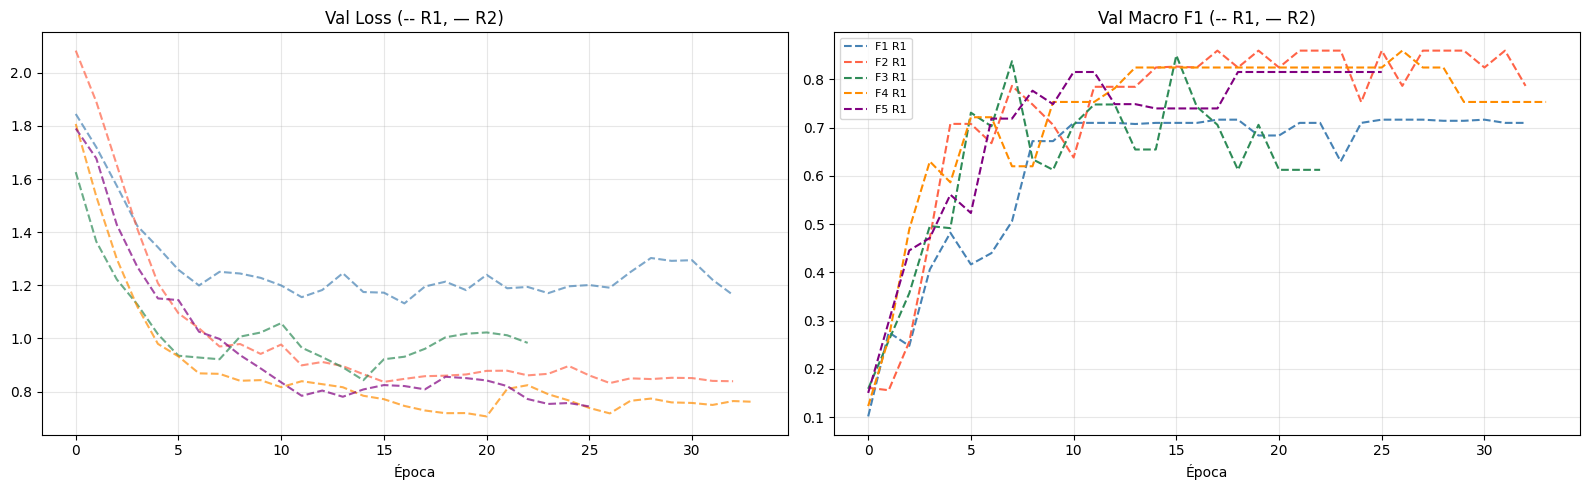

In [34]:
hist_r1 = pd.DataFrame(all_history)
#hist_r2 = pd.DataFrame(r2_history)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = ["steelblue", "tomato", "seagreen", "darkorange", "purple"]

for rnd, (hist, results, label) in enumerate([
    (hist_r1, fold_results, "R1"),
    #(hist_r2, r2_results,   "R2"),
], 1):
    for fold_n in range(1, CFG["n_folds"] + 1):
        fd = hist[hist["fold"] == fold_n]
        ls = "-" if rnd == 2 else "--"
        c  = colors[fold_n - 1]
        axes[0].plot(range(len(fd)), fd["val_loss"],  color=c, ls=ls, alpha=0.7)
        axes[1].plot(range(len(fd)), fd["val_f1"],    color=c, ls=ls,
                     label=f"F{fold_n} {label}")

axes[0].set_title("Val Loss (-- R1, — R2)")
axes[1].set_title("Val Macro F1 (-- R1, — R2)")
#axes[1].axhline(np.mean(r2_results), color="black", ls=":",
#                label=f"R2 media={np.mean(r2_results):.3f}")
for ax in axes: ax.set_xlabel("Época"); ax.grid(True, alpha=0.3)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / "curves_r1_r2.png", dpi=120)
plt.show()

## 10 · Inferencia final: ensemble R1 + R2 con TTA

In [35]:
# Elegir qué checkpoints usar: R2 si mejoró, sino R1
r2_results = []
use_r2 = np.mean(r2_results) >= np.mean(fold_results) - 0.01
best_ckpts = r2_ckpts if use_r2 else fold_ckpts
print(f"Usando checkpoints de {'Ronda 2' if use_r2 else 'Ronda 1'}")
print(f"  R1 media: {np.mean(fold_results):.4f}")
print(f"  R2 media: {np.mean(r2_results):.4f}")

# Cargar ensemble
torch.backends.cudnn.benchmark = True 
final_models = [load_model_for_inference(p) for p in best_ckpts]
print(f"\n{len(final_models)} modelos cargados para inferencia")

# Re-cargar test_ds (puede haber cambiado el directorio)
test_ds = SheepDataset(str(PROCESSED_DIR / "test"), n_frames=CFG["n_frames"], is_train=False)

results = []
for idx in tqdm(range(len(test_ds)), desc="Inferencia final TTA"):
    vid_id = test_ds.samples[idx][0]
    frames = test_ds._load_frames(vid_id)
    probs  = ensemble_predict_proba(final_models, frames, n_tta=CFG["tta_augments"])
    results.append({"Id": vid_id, "Predicted": int(probs.argmax())})

submission = pd.DataFrame(results)
print(f"\n✅ {len(submission)} predicciones")
print("Distribución:", dict(submission["Predicted"].value_counts().sort_index()))

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Usando checkpoints de Ronda 1
  R1 media: 0.8203
  R2 media: nan
  Params totales: 4.01M | Entrenables: 0.00M (0.0%)
  Params totales: 4.01M | Entrenables: 0.00M (0.0%)
  Params totales: 4.01M | Entrenables: 0.00M (0.0%)
  Params totales: 4.01M | Entrenables: 0.00M (0.0%)
  Params totales: 4.01M | Entrenables: 0.00M (0.0%)

5 modelos cargados para inferencia
  Dataset: 169 muestras (val/test)


Inferencia final TTA:   0%|          | 0/169 [00:00<?, ?it/s]


✅ 169 predicciones
Distribución: {0: np.int64(47), 1: np.int64(22), 2: np.int64(24), 3: np.int64(63), 4: np.int64(13)}


## 11. Fallback: No se ejecuta psudo-labeling

In [36]:
# Saltar Ronda 2 con pseudo-labels
# En su lugar: entrenamiento final con TODOS los datos de train
# y fine-tuning más profundo (unfreeze más bloques)

print("Confianza insuficiente para pseudo-labeling confiable.")
print("Procediendo directamente al entrenamiento final con todos los datos.\n")

# Usar todos los datos de train sin fold de validación
full_df = df.copy()
full_os = oversample_df(full_df, strategy="max")  # max en lugar de median
print(f"Muestras tras oversample: {len(full_os)}")
print(full_os["Target"].value_counts().sort_index())

full_ds = SheepDataset(
    str(PROCESSED_DIR / "train"), full_os,
    n_frames=CFG["n_frames"], is_train=True
)
full_sampler = make_sampler(full_os["Target"].tolist())
full_loader  = DataLoader(
    full_ds, batch_size=CFG["batch_size"],
    sampler=full_sampler,
    num_workers=CFG["num_workers"], pin_memory=True, drop_last=True,
)

# Fase 1: backbone congelado, más épocas
set_seed(CFG["seed"])
final_model = build_model(unfreeze=0)
criterion   = SmoothedCE(CFG["label_smoothing"], CFG["num_classes"])
optimizer   = make_optimizer(final_model, lr=3e-4)
scheduler   = cosine_warmup(optimizer, 3, 40)
scaler      = GradScaler("cuda")

print("\n── Fase 1: solo clasificador, 40 épocas ──")
for epoch in range(1, 41):
    m = run_epoch(final_model, full_loader, optimizer, criterion, scaler, True)
    scheduler.step()
    print(f"  Ep {epoch:3d} | Loss={m['loss']:.4f} | F1={m['macro_f1']:.4f}")

torch.save({"model_state": final_model.state_dict(), "cfg": CFG},
           CHECKPOINT_DIR / "final_phase1.pt")

# Fase 2: descongelar más bloques con LR bajo
print("\n── Fase 2: fine-tuning 5 bloques, 30 épocas ──")
final_model._set_frozen(unfreeze_last_n=5)
optimizer2  = make_optimizer(final_model, lr=2e-5)
scheduler2  = cosine_warmup(optimizer2, 3, 30)

best_f1_final = 0.0

for epoch in range(1, 31):
    m = run_epoch(final_model, full_loader, optimizer2, criterion, scaler, True)
    scheduler2.step()
    print(f"  Ep {epoch:3d} | Loss={m['loss']:.4f} | F1={m['macro_f1']:.4f}")

    if m["macro_f1"] > best_f1_final:
        best_f1_final = m["macro_f1"]
        torch.save({"model_state": final_model.state_dict(), "cfg": CFG},
                   CHECKPOINT_DIR / "final_best.pt")
        print(f"    ✓ Mejor guardado (F1={best_f1_final:.4f})")
    
print("\n💾 Modelo final guardado")

Confianza insuficiente para pseudo-labeling confiable.
Procediendo directamente al entrenamiento final con todos los datos.

Muestras tras oversample: 145
Target
0    29
1    29
2    29
3    29
4    29
Name: count, dtype: int64
  Dataset: 145 muestras (train)
  Params totales: 4.01M | Entrenables: 0.00M (0.0%)

── Fase 1: solo clasificador, 40 épocas ──


 Train:   0%|          | 0/9 [00:00<?, ?it/s]

  Ep   1 | Loss=2.9959 | F1=0.1174


 Train:   0%|          | 0/9 [00:00<?, ?it/s]

  Ep   2 | Loss=2.5181 | F1=0.2362


...

  Ep  28 | Loss=0.9806 | F1=0.6686


 Train:   0%|          | 0/9 [00:00<?, ?it/s]

  Ep  29 | Loss=1.0434 | F1=0.7401


 Train:   0%|          | 0/9 [00:00<?, ?it/s]

  Ep  30 | Loss=0.9781 | F1=0.5530

💾 Modelo final guardado


## Nueva inferencia

In [37]:
# Usar el mejor modelo final + ensemble de folds de Ronda 1
torch.backends.cudnn.benchmark = True

# Cargar modelo final (el mejor de fase 2)
final_inference = load_model_for_inference(str(CHECKPOINT_DIR / "final_best.pt"))

# Cargar los 5 folds de Ronda 1
r1_models = [load_model_for_inference(p) for p in fold_ckpts]

# Ensemble: modelo final + 5 folds
all_models = [final_inference] + r1_models
print(f"{len(all_models)} modelos en el ensemble (1 final + {len(r1_models)} folds R1)")

test_ds = SheepDataset(str(PROCESSED_DIR / "test"), n_frames=CFG["n_frames"], is_train=False)
print(f"Videos de test: {len(test_ds)}")

results = []
for idx in tqdm(range(len(test_ds)), desc="Inferencia final TTA"):
    vid_id = test_ds.samples[idx][0]
    frames = test_ds._load_frames(vid_id)
    probs  = ensemble_predict_proba(all_models, frames, n_tta=CFG["tta_augments"])
    results.append({"Id": vid_id, "Predicted": int(probs.argmax())})

submission = pd.DataFrame(results)
print(f"\n✅ {len(submission)} predicciones")
print("Distribución:", dict(submission["Predicted"].value_counts().sort_index()))

  Params totales: 4.01M | Entrenables: 0.00M (0.0%)
  Params totales: 4.01M | Entrenables: 0.00M (0.0%)
  Params totales: 4.01M | Entrenables: 0.00M (0.0%)
  Params totales: 4.01M | Entrenables: 0.00M (0.0%)
  Params totales: 4.01M | Entrenables: 0.00M (0.0%)
  Params totales: 4.01M | Entrenables: 0.00M (0.0%)
6 modelos en el ensemble (1 final + 5 folds R1)
  Dataset: 169 muestras (val/test)
Videos de test: 169


Inferencia final TTA:   0%|          | 0/169 [00:00<?, ?it/s]


✅ 169 predicciones
Distribución: {0: np.int64(45), 1: np.int64(23), 2: np.int64(27), 3: np.int64(64), 4: np.int64(10)}


In [38]:
SUBMISSION_PATH = WORKING_DIR / "submission.csv"
submission.to_csv(SUBMISSION_PATH, index=False)

df_check = pd.read_csv(SUBMISSION_PATH)
assert list(df_check.columns) == ["Id", "Predicted"]
assert df_check["Predicted"].between(0, 4).all()
assert df_check["Id"].nunique() == len(df_check)
assert df_check.isnull().sum().sum() == 0

print(f"✅ Submission válido · {len(df_check)} filas")
print(f"💾 Guardado: {SUBMISSION_PATH}")
submission.head(10)

✅ Submission válido · 169 filas
💾 Guardado: /kaggle/working/submission.csv


,Id,Predicted
0,0110a1cb437b4038,1
1,016d9242af8f4577,3
2,02b1ee35fffd48c3,3
3,048667609337485b,3
4,07de584e7b684894,3
5,0800d01f5f6f4d5f,2
6,09a42f65c05a491d,2
7,0bb5c8ce46864d68,3
8,0bf83d8fa4884298,0
9,0dc94147ad7247e4,0
